<a href="https://colab.research.google.com/github/be0wulf2001/Machine-Learning-Lab/blob/main/Linear_Regression_and_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
data = fetch_california_housing()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# -------------------------------
# Linear Regression - Normal Equation
# -------------------------------

X_train_ne = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_ne = np.c_[np.ones(X_test.shape[0]), X_test]

theta = np.linalg.inv(
    X_train_ne.T @ X_train_ne
) @ X_train_ne.T @ y_train

y_pred_ne = X_test_ne @ theta

mse_ne = mean_squared_error(y_test, y_pred_ne)
r2_ne = r2_score(y_test, y_pred_ne)

In [ ]:
# -------------------------------
# Linear Regression - Gradient Descent
# -------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_gd = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_gd = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

theta_gd = np.zeros(X_train_gd.shape[1])

learning_rate = 0.01
iterations = 10000
m = len(y_train)

for i in range(iterations):
    gradients = (2 / m) * X_train_gd.T @ (
        X_train_gd @ theta_gd - y_train
    )
    theta_gd -= learning_rate * gradients

y_pred_gd = X_test_gd @ theta_gd

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

In [ ]:
# -------------------------------
# Sklearn Linear Regression
# -------------------------------

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [ ]:
# -------------------------------
# Ridge Regression
# -------------------------------

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

In [ ]:
# -------------------------------
# Lasso Regression
# -------------------------------

lasso_model = Lasso(alpha=0.01)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

In [ ]:
# -------------------------------
# Results
# -------------------------------

print("Linear Regression - Normal Equation")
print("MSE:", mse_ne)
print("R2 Score:", r2_ne)

print("\nLinear Regression - Gradient Descent")
print("MSE:", mse_gd)
print("R2 Score:", r2_gd)

print("\nLinear Regression - Scikit-learn")
print("MSE:", mse_lr)
print("R2 Score:", r2_lr)

print("\nRidge Regression")
print("MSE:", mse_ridge)
print("R2 Score:", r2_ridge)

print("\nLasso Regression")
print("MSE:", mse_lasso)
print("R2 Score:", r2_lasso)

Linear Regression - Normal Equation
MSE: 0.5558915986959397
R2 Score: 0.5757877060319201

Linear Regression - Gradient Descent
MSE: 0.5558926986491989
R2 Score: 0.575786866635001

Linear Regression - Scikit-learn
MSE: 0.5558915986952422
R2 Score: 0.5757877060324524

Ridge Regression
MSE: 0.5558034669932196
R2 Score: 0.5758549611440138

Lasso Regression
MSE: 0.5444491581246521
R2 Score: 0.5845196673976367


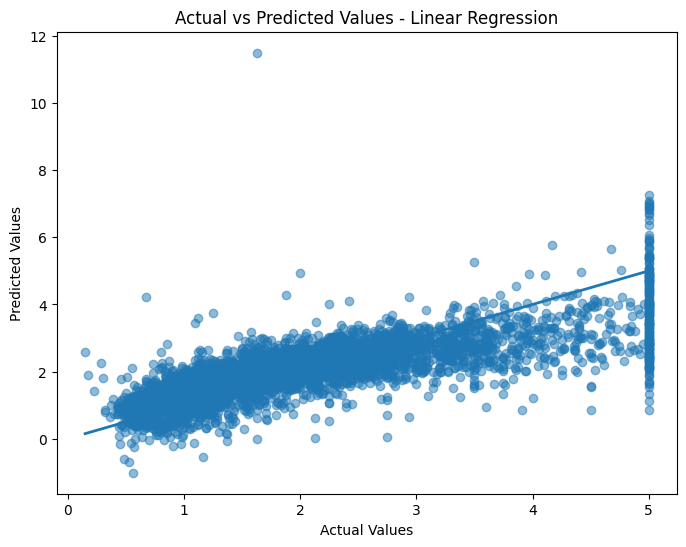

In [ ]:
# -------------------------------
# Predicted vs Actual
# -------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values - Linear Regression")
plt.show()

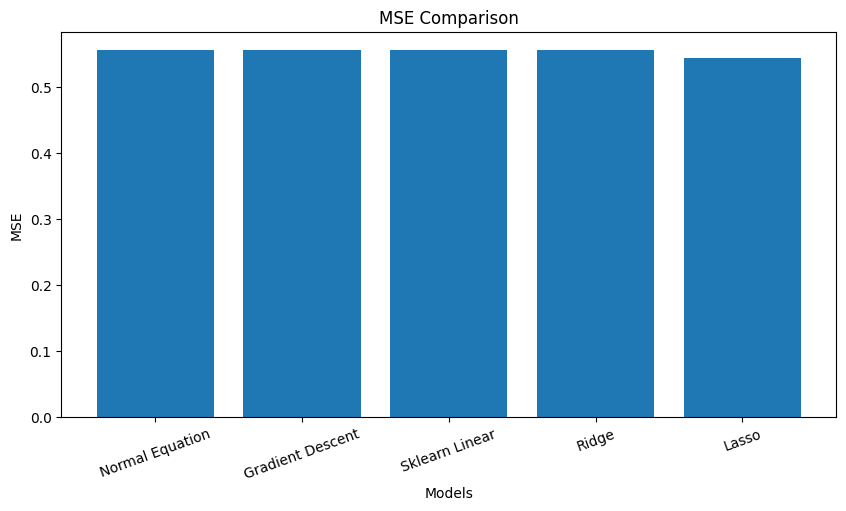

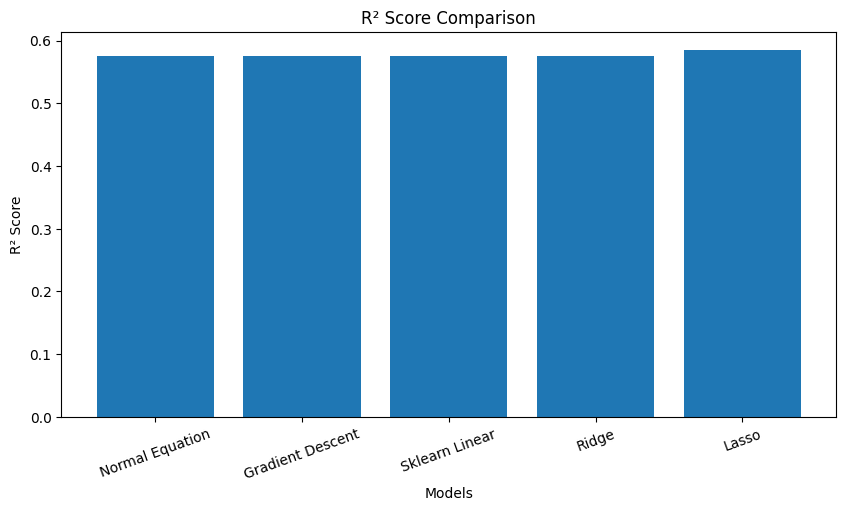

In [ ]:
# -------------------------------
# Compare Models
# -------------------------------

models = [
    "Normal Equation",
    "Gradient Descent",
    "Sklearn Linear",
    "Ridge",
    "Lasso"
]

mse_values = [
    mse_ne,
    mse_gd,
    mse_lr,
    mse_ridge,
    mse_lasso
]

r2_values = [
    r2_ne,
    r2_gd,
    r2_lr,
    r2_ridge,
    r2_lasso
]

plt.figure(figsize=(10, 5))

plt.bar(models, mse_values)

plt.xlabel("Models")
plt.ylabel("MSE")
plt.title("MSE Comparison")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(10, 5))

plt.bar(models, r2_values)

plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("R² Score Comparison")
plt.xticks(rotation=20)
plt.show()